## **Figure-S15**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np
import os
import re

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator
import seaborn as sns

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(silico='in-silico',
             bruker='timsTOF, 2024',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based')

#### **Load Data - DIA-NN**

In [4]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'-(\d+pg)-', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderDiann(diann_dir, **kwargs):
    # Define custom sort order for dilutions
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']

    rslts = {i:defaultdict(dict) for i in dilution_order} 

    # Get all dilution directories within diann directory
    dilution_dirs = []
    if os.path.isdir(diann_dir):
        dilution_dirs = [d for d in os.listdir(diann_dir) 
                        if os.path.isdir(os.path.join(diann_dir, d))
                        ]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(diann_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            lib_dirs = [d for d in os.listdir(replicate_path) 
                       if os.path.isdir(os.path.join(replicate_path, d))
                       and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, "report.tsv")

                lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists
                if os.path.exists(report_path):
                    try:
                        # Call getPrecursorSetDiann function
                        if lib_dilution == '5000pg':
                            if dilution_dir != '0pg':
                                # Store both the result and the library name
                                rslts[dilution_dir][replicate][condition['refined']] = getPrecursorSetDiann(report_path, **kwargs)
    
                                print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
                    except Exception as e:
                        print(f"Error processing {report_path}: {str(e)}")
                else:
                    print(f"Missing report.tsv file in {os.path.join(replicate_path, lib_dir)}")
    return rslts


def appendOriginalResultsDiann(diann_dir, rslts, **kwargs):
    # Get all experiment directories within diann directory
    diann_experiment_dirs = []
    if os.path.isdir(diann_dir):
        diann_experiment_dirs = [d for d in os.listdir(diann_dir) 
                               if os.path.isdir(os.path.join(diann_dir, d)) and '_0pg' not in d and "R2024" not in d]
    
    # Process each directory
    for dir_name in diann_experiment_dirs:
        # Extract dilution and replicate
        dilution, replicate = extract_info(dir_name)
        
        # Path to report.tsv
        report_path = os.path.join(diann_dir, dir_name, "report.tsv")

        # Check if file exists
        if os.path.exists(report_path):
            try:
                if dilution != '0pg':
                    rslts[dilution][replicate][condition['orig']] = getPrecursorSetDiann(report_path, **kwargs)
                    print(f"Processed {dir_name} successfully (dilution: {dilution}, replicate: {replicate})")
            except Exception as e:
                print(f"Error processing {dir_name}: {str(e)}")
        else:
            print(f"Skipping {dir_name}: Missing report.tsv file")

In [5]:
diann = {}

diann[names['bruker']] = loadRefinedFolderDiann("../../results/SCP-Bruker-Lib-Refined-Analysis/diann/")
appendOriginalResultsDiann("../../results/SCP-Bruker-Library-Analysis/diann/", diann[names['bruker']])

diann[names['silico']] = loadRefinedFolderDiann("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-PeptDeep-NoMods-Analysis/diann/", diann[names['silico']])

diann[names['diatracer']] = loadRefinedFolderDiann("../../results/SCP-diaTracer-Refined-Analysis/diann/", infer_schema_length=100000)
appendOriginalResultsDiann("../../results/SCP-diaTracer-Analysis/diann", diann[names['diatracer']], infer_schema_length=100000)

../../results/SCP-Bruker-Lib-Refined-Analysis/diann/250pg/HeLa02DDM_250pg_5x3_PyDIA_8_S2-C8_1_1723/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
Processed 250pg rep 8 | lib dilution 5000pg | lib directory 2025-06-17-Refine-BrukerLib-5000pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/250pg/HeLa02DDM_250pg_5x3_PyDIA_4_S2-A7_1_1719/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
Processed 250pg rep 4 | lib dilution 5000pg | lib directory 2025-06-17-Refine-BrukerLib-5000pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/250pg/HeLa02DDM_250pg_5x3_PyDIA_2_S1-C8_1_1637/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
Processed 250pg rep 2 | lib dilution 5000pg | lib directory 2025-06-17-Refine-BrukerLib-5000pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/250pg/HeLa02DDM_250pg_5x3_PyDIA_3_S1-C9_1_1638/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
Processed 250pg rep 3 | lib dilution 5000pg | lib directory 2025-06-17-R

#### **Load Data - OSW**

In [6]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, **kwargs):
    # Dictionary to store results by dilution and replicate
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']
    rslts = {i:defaultdict(dict) for i in dilution_order} 


    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'\d+pg', d) 
                        ]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        if dilution_dir == '0pg':
            continue
        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            if alt_lib_dir:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                        if os.path.isdir(os.path.join(replicate_path, d))
                        and d.startswith('lib')]
            else:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                           if os.path.isdir(os.path.join(replicate_path, d))
                           and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                    
                if alt_lib_dir:
                    lib_dilution = extract_lib_info_alt(lib_dir)
                else:
                    lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists, if not use pyprophet fallback
                if not os.path.exists(report_path):
                        report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )
                if lib_dilution == '5000pg':
                    if lib_dilution != dilution_dir:
                        rslts[dilution_dir][replicate][condition['refined']] = getPrecursorSet_oswpq(report_path)
                        print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
    return rslts

def appendOriginalResultsOSW(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'\d+pg', d) ]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        print(dilution_dir)
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if dilution == '0':
            continue
        report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
        print(report_path)
        
        # Check if file exists, if not use pyprophet fallback
        if not os.path.exists(report_path):
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
        
        rslts[dilution][replicate][condition['orig']] = getPrecursorSet_oswpq(report_path)
        print(f"Processed {dilution_dir} rep {replicate} | lib original")
        
def appendOriginalResultsOSWDiaTracer(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'\d+pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:

        dilution_path = os.path.join(osw_dir, dilution_dir)

        runName_dirs = [d for d in os.listdir(os.path.join(osw_dir, dilution_dir)) 
                        if os.path.isdir(os.path.join(osw_dir, dilution_dir, d))
                        and re.search(r'pg', d)]

        if dilution_dir == '0pg':
            continue
        for runName in runName_dirs: 
            dilution, replicate = extract_info(runName)

            report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_folder, runName + ".oswpq")

            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_fallback, runName + ".oswpq/" )

            if not os.path.exists(report_path):
                continue
                
            rslts[dilution][replicate][condition['orig']] = getPrecursorSet_oswpq(report_path)
            print(f"Processed {dilution_dir} rep {replicate} | lib original")

In [7]:
osw = {}

osw[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", osw[names['bruker']])

osw[names['diatracer']] = loadRefinedFolderOSW("../../results/SCP-diaTracer-Refined-Analysis/osw/", alt_lib_dir=True)
appendOriginalResultsOSWDiaTracer("../../results/SCP-diaTracer-Analysis/osw/", osw[names['diatracer']])

# note it is SVM even though it is in the LDA folder
osw[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", osw[names['silico']], pyprophet_folder='pyprophet_SVM')

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_5000pg_5x3_PyDIA_2_S1-D8_1_1661_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 5000pg | lib directory HeLa02DDM_5000pg_5x3_PyDIA_2_S1-D8_1_1661_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713/HeLa02DDM_5000pg_5x3_PyDIA_2_S1-D8_1_1661_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713.oswpq/
Processed 100pg rep 4 | lib dilution 5000pg | lib directory HeLa02DDM_5000pg_5x3_PyDIA_2_S1-D8_1_1661_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718/HeLa02DDM_5000pg_5x3_PyDIA_2_S1-D8_1_1661_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718.oswpq/
Processed 100pg rep 9 | lib dilution 5000pg | lib directory HeLa02DDM_5000pg_5x3_PyDIA_2_S1-D8_1_1661_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_1

#### **Format For Plot**

Here going to create start plots for each library. The idea is that facet by different libraries. Show that there is a tradeoff between reproducibility and identification rates and depending on the diluti0on step that refine with that tradeoff changes. 

In [8]:
def format_for_plot(ids):
    df = []
    for lib in ids.keys():
        for dil in ids['timsTOF, 2024'].keys():
            #print(pd.DataFrame(ids[lib][dil]).map(lambda x: len(x) if isinstance(x, set) else 0).reset_index(names=['Condition']).melt(id_vars='Condition', var_name='Replicate', value_name='# Peptide Precursors'))

            tmp = pd.DataFrame(ids[lib][dil]).fillna({}).map(lambda x: len(x) if isinstance(x, set) else 0).reset_index(names=['Condition']).melt(id_vars='Condition', var_name='Replicate', value_name='# Peptide Precursors')
            tmp['Library'] = lib
            tmp['Dilution'] = dil

            # exclude those runs that failed
            no_ids = tmp[tmp['# Peptide Precursors'] == 0]['Replicate'].drop_duplicates().values
            tmp = tmp[~tmp['Replicate'].isin(no_ids)].copy()
            
            df.append(tmp)

    #return df
    df = pd.concat(df)
    df = df.pivot(index=['Dilution', 'Library', 'Replicate'], columns=['Condition'], values='# Peptide Precursors').reset_index()
    
    df['FoldChange'] = df[condition['refined']] / df[condition['orig']]
    df['DilutionName'] = df['Dilution']
    df['Dilution'] = df['DilutionName'].str.extract(r'(\d*)').astype(int)
    return df

In [9]:
diann_df = format_for_plot(diann)
osw_df = format_for_plot(osw)

In [10]:
palette = sns.color_palette(["tab:orange", "tab:green", "tab:purple"])
def plot_fold_change(ax, ids, show_xlabel=False, show_legend=False):
    #kwargs = dict(errorbar='sd', estimator='median')
    kwargs = dict(errorbar=('ci', 95), estimator='median') # no error bar for cleaner look
    #kwargs = dict()
        
    # Map the line plot for fold changes
    sns.lineplot(x="Dilution", y="FoldChange", data=ids, hue='Library', 
                 marker="o", markersize=7, linewidth=2.5, hue_order=names.values(), legend=show_legend, palette=palette,
                 **kwargs, ax=ax)
    
    # Set scales
    ax.set_xscale('log')
    ax.set_yscale('symlog', linthresh=2)
    
    # Clean up ticks
    ax.set_xticks([100, 250, 500, 1000, 2500])
    ax.set_xticklabels(['100', '250', '500', '1000', '2500'])
    ax.set_yticks([1, 2, 3, 10])
    ax.set_yticklabels(['1', '2', '3', '10'])
    ax.yaxis.set_minor_locator(FixedLocator([]))
    #ax.set_ylim(0, 20)
    # Labels and limits
    
    ax.set_ylabel('Fold Change\n(# Precursors Identified)', fontsize=11)
    
    if show_xlabel:
        ax.set_xlabel('Sample Load (pg)', fontsize=12)
    else:
        ax.set_xlabel("")
    
    ax.set_ylim(0.5, 15)
    ax.axhline(y=1, color='black')
    
    # Cleaner grid
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    if show_legend:
        leg = ax.legend(fontsize=10, 
              frameon=True, fancybox=False, shadow=False, loc='lower center', bbox_to_anchor=(0.5, -0.4), ncols=5)
        leg.get_texts()[0].set_style('italic')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Slightly larger tick labels
    ax.tick_params(labelsize=10)

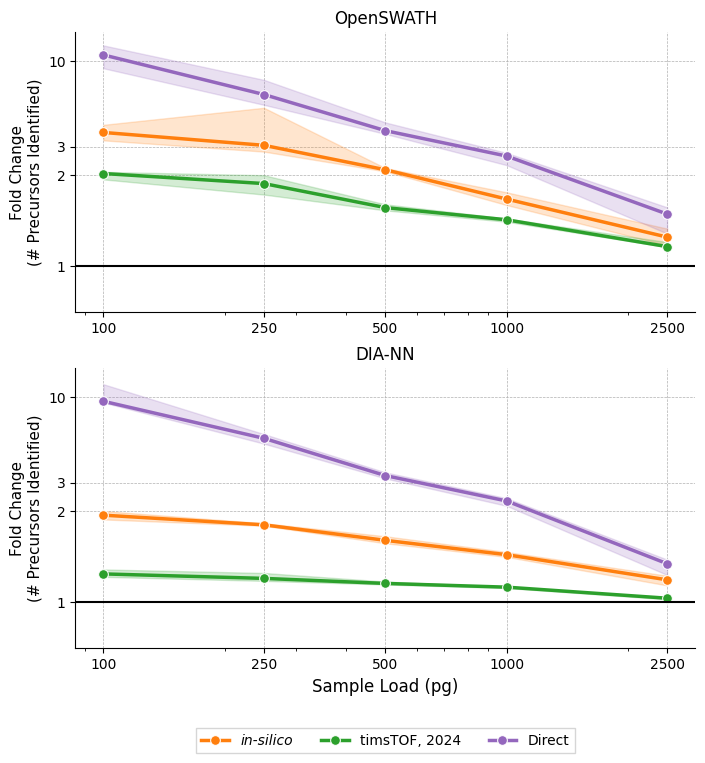

In [11]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8, 8))
plot_fold_change(ax1, osw_df, show_legend=False, show_xlabel=False)
plot_fold_change(ax2, diann_df, show_legend=True, show_xlabel=True)
ax1.set_title('OpenSWATH', fontsize=12)
ax2.set_title('DIA-NN', fontsize=12)

plt.savefig("Figure-S15.png", dpi=300, bbox_inches='tight')
